In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os

from lameg.util import load_meg_sensor_data


In [2]:
plt.rcParams.update({
    'font.size': 16,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

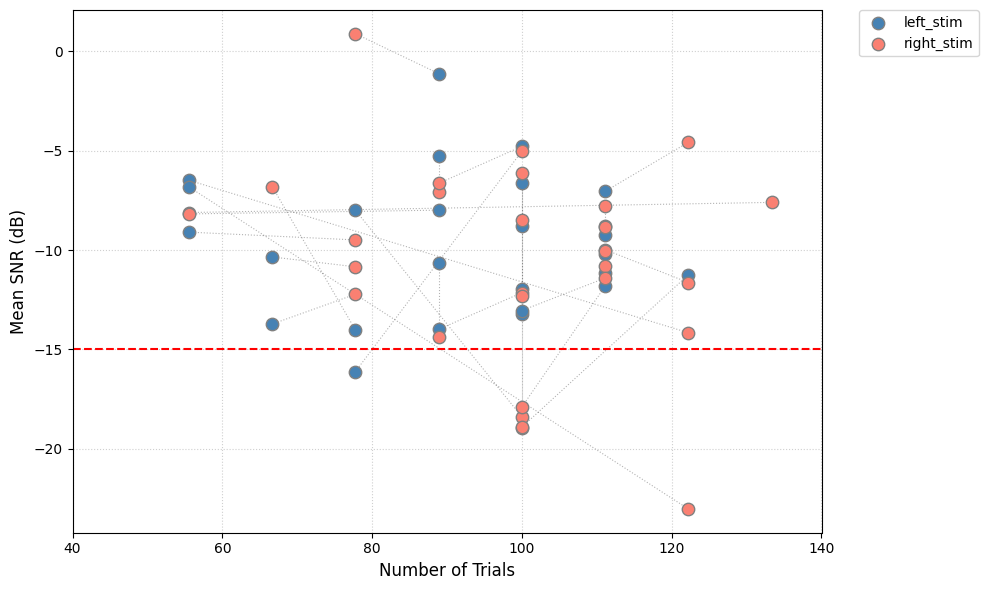

In [19]:

def upload_meg_file(rawdata_path, sub, ses, condition):
    """
    Search and upload the raw datachunck

    :param rawdata_path: datapath
    :param sub: subjects id
    :param ses: session id 
    :param condition: experimental condition (block-wise)
    """
    
    sub_meg_path = os.path.join(rawdata_path, "sub-" + sub , "ses-0" + ses , "meg/sub-"+ sub + "_ses-0" + ses + "_task-" + condition + "_acq-")
    folders_acq = glob.glob(sub_meg_path + "*_meg.ds", recursive=True)
    list_folders = sorted(folders_acq, key=lambda x: int(x.split('acq-')[1].split('_')[0]))
    
    return list_folders

n_layers=11
subj_ra_idx = {}

time_lims=[50,150]
out_dir="/home/membercophy/Matteo_M/V1_ERF/results"
braindyn_files = "/home/membercophy/Matteo_M/V1_ERF/BrainDyn_Data/Data/MRI"
figures_path = ""
meg_rawdata_path = "/home/membercophy/Matteo_M/V1_ERF/rawdata"


SUB = ['105', '107', '109', '113', '114',
        '115', '117','118','119', '123', 
        '124', '126','127','129', '130',
        '131','132','133','134', '135', 
        '136', '137','138', '141','142',
        '143','144','145']

ses = "1"
condition = "V100V100"
mxf_option = "no_mxf" 

triggers = {"left_stim": "steelblue", "right_stim": "salmon"}
plot_data = {}

for trigger, color in triggers.items():
    snrs_subj = []
    total_trials_sub = []

    for s, sub in enumerate(SUB): 
        
        list_folders = upload_meg_file(meg_rawdata_path, sub, ses, condition)
        mxf_path_dir = os.path.join(list_folders[-1], f"mxf_{mxf_option}_data")

        output_spm_conv_dir = os.path.join(mxf_path_dir, "mxf_sess_data", "spm_convert_epo")
        spm_converted_file = f"spm_sub-{sub}_ses-0{ses}_task-{condition}_meg_{mxf_option}_{trigger}_nrg_ERF_epo"
        base_fname = os.path.join(output_spm_conv_dir,spm_converted_file + ".mat")

        sensor_data, sensor_time, ch_names = load_meg_sensor_data(base_fname)
        st_idx=np.where((sensor_time>=time_lims[0]) & (sensor_time<=time_lims[1]))[0]
        sensor_data=sensor_data[:,st_idx,:]
        total_trials = sensor_data.shape[2]

        sensor_time=sensor_time[st_idx]
        mean_signal = np.mean(sensor_data, axis=2)
        noise = sensor_data - mean_signal[:, :, np.newaxis]
        rms_signal = np.sqrt(np.mean(mean_signal**2, axis=0))  # shape: (n_times,)
        rms_noise = np.sqrt(np.mean(np.mean(noise**2, axis=2), axis=0))  # shape: (n_times,)
        snr_db = 20 * np.log10(rms_signal / rms_noise)

        snrs_subj.append(snr_db)
        total_trials_sub.append(total_trials)


    snrs_all = np.array(snrs_subj)
    mean_snr_sub = np.mean(snrs_all, axis=1)
    total_trials_sub = np.array(total_trials_sub)

    plot_data[trigger] = {
    'y': np.array(mean_snr_sub),
    'x': np.array(total_trials_sub),
    'color': color
    }

plt.figure(figsize=(10, 6))
snr_lim = -15
trigger_keys = list(triggers.keys())
bins = np.linspace(50, 150, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2

if len(trigger_keys) == 2:
    t1, t2 = trigger_keys[0], trigger_keys[1]
    t1_bin_idx = np.clip(np.digitize(plot_data[t1]['x'], bins) - 1, 0, len(bin_centers) - 1)
    t2_bin_idx = np.clip(np.digitize(plot_data[t2]['x'], bins) - 1, 0, len(bin_centers) - 1)
    
    t1_binned_x = bin_centers[t1_bin_idx]
    t2_binned_x = bin_centers[t2_bin_idx]
    
    for i in range(len(SUB)):
        plt.plot([t1_binned_x[i], t2_binned_x[i]], 
                 [plot_data[t1]['y'][i], plot_data[t2]['y'][i]], 
                 color='black', alpha=0.3, linestyle=":", linewidth=0.8, zorder=1)

for trigger, data in plot_data.items():
    binned_indices = np.digitize(data['x'], bins) - 1
    
    binned_indices = np.clip(binned_indices, 0, len(bin_centers) - 1)
    
    x_binned_values = bin_centers[binned_indices]
    
    plt.scatter(x_binned_values, data['y'], color=data['color'], 
                label=trigger, s=80, edgecolors='gray', zorder=2)
    
plt.xlabel("Number of Trials", fontsize=12)
plt.ylabel("Mean SNR (dB)", fontsize=12)
plt.axhline(y=snr_lim, color='r', linestyle='--')
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(40, 140)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

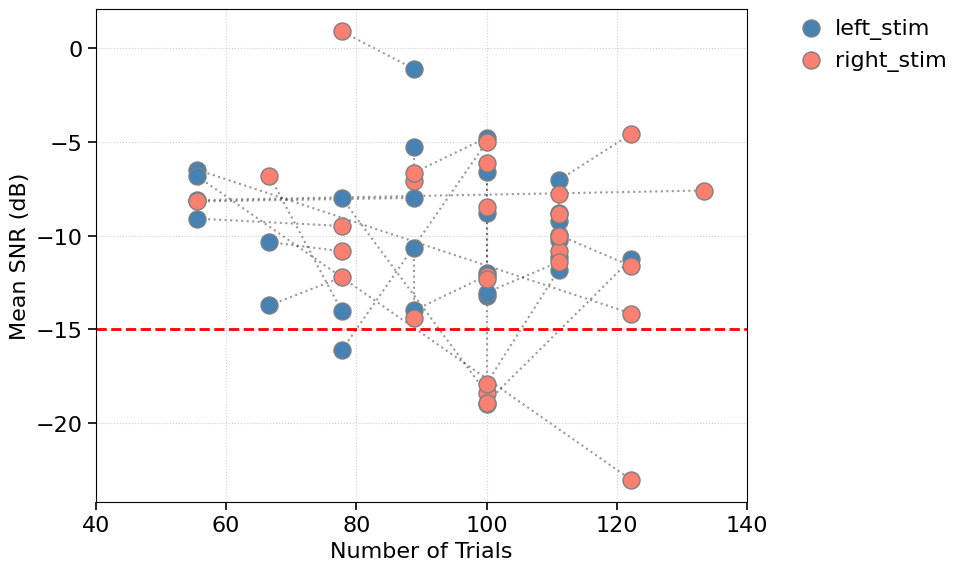

In [3]:



def upload_meg_file(rawdata_path, sub, ses, condition):
    """
    Search and upload the raw datachunck

    :param rawdata_path: datapath
    :param sub: subjects id
    :param ses: session id 
    :param condition: experimental condition (block-wise)
    """
    
    sub_meg_path = os.path.join(rawdata_path, "sub-" + sub , "ses-0" + ses , "meg/sub-"+ sub + "_ses-0" + ses + "_task-" + condition + "_acq-")
    folders_acq = glob.glob(sub_meg_path + "*_meg.ds", recursive=True)
    list_folders = sorted(folders_acq, key=lambda x: int(x.split('acq-')[1].split('_')[0]))
    
    return list_folders

n_layers=11
subj_ra_idx = {}

time_lims=[50,150]
out_dir="/home/membercophy/Matteo_M/V1_ERF/results"
braindyn_files = "/home/membercophy/Matteo_M/V1_ERF/BrainDyn_Data/Data/MRI"
figures_path = ""
meg_rawdata_path = "/home/membercophy/Matteo_M/V1_ERF/rawdata"


SUB = ['105', '107', '109', '113', '114',
        '115', '117','118','119', '123', 
        '124', '126','127','129', '130',
        '131','132','133','134', '135', 
        '136', '137','138', '141','142',
        '143','144','145']

ses = "1"
condition = "V100V100"
mxf_option = "no_mxf" 

triggers = {"left_stim": "steelblue", "right_stim": "salmon"}
plot_data = {}

for trigger, color in triggers.items():
    snrs_subj = []
    total_trials_sub = []

    for s, sub in enumerate(SUB): 
        
        list_folders = upload_meg_file(meg_rawdata_path, sub, ses, condition)
        mxf_path_dir = os.path.join(list_folders[-1], f"mxf_{mxf_option}_data")

        output_spm_conv_dir = os.path.join(mxf_path_dir, "mxf_sess_data", "spm_convert_epo")
        spm_converted_file = f"spm_sub-{sub}_ses-0{ses}_task-{condition}_meg_{mxf_option}_{trigger}_nrg_ERF_epo"
        base_fname = os.path.join(output_spm_conv_dir,spm_converted_file + ".mat")

        sensor_data, sensor_time, ch_names = load_meg_sensor_data(base_fname)
        st_idx=np.where((sensor_time>=time_lims[0]) & (sensor_time<=time_lims[1]))[0]
        sensor_data=sensor_data[:,st_idx,:]
        total_trials = sensor_data.shape[2]

        sensor_time=sensor_time[st_idx]
        mean_signal = np.mean(sensor_data, axis=2)
        noise = sensor_data - mean_signal[:, :, np.newaxis]
        rms_signal = np.sqrt(np.mean(mean_signal**2, axis=0))  # shape: (n_times,)
        rms_noise = np.sqrt(np.mean(np.mean(noise**2, axis=2), axis=0))  # shape: (n_times,)
        snr_db = 20 * np.log10(rms_signal / rms_noise)

        snrs_subj.append(snr_db)
        total_trials_sub.append(total_trials)


    snrs_all = np.array(snrs_subj)
    mean_snr_sub = np.mean(snrs_all, axis=1)
    total_trials_sub = np.array(total_trials_sub)

    plot_data[trigger] = {
    'y': np.array(mean_snr_sub),
    'x': np.array(total_trials_sub),
    'color': color
    }

plt.figure(figsize=(10, 6))
snr_lim = -15
trigger_keys = list(triggers.keys())
bins = np.linspace(50, 150, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2

if len(trigger_keys) == 2:
    t1, t2 = trigger_keys[0], trigger_keys[1]
    t1_bin_idx = np.clip(np.digitize(plot_data[t1]['x'], bins) - 1, 0, len(bin_centers) - 1)
    t2_bin_idx = np.clip(np.digitize(plot_data[t2]['x'], bins) - 1, 0, len(bin_centers) - 1)
    
    t1_binned_x = bin_centers[t1_bin_idx]
    t2_binned_x = bin_centers[t2_bin_idx]
    
    for i in range(len(SUB)):
        # Thicker lines: linewidth set to 1.5
        plt.plot([t1_binned_x[i], t2_binned_x[i]], 
                 [plot_data[t1]['y'][i], plot_data[t2]['y'][i]], 
                 color='black', alpha=0.4, linestyle=":", linewidth=1.5, zorder=1)

for trigger, data in plot_data.items():
    binned_indices = np.digitize(data['x'], bins) - 1
    binned_indices = np.clip(binned_indices, 0, len(bin_centers) - 1)
    x_binned_values = bin_centers[binned_indices]
    
    # Larger dots: s increased to 150
    plt.scatter(x_binned_values, data['y'], color=data['color'], 
                label=trigger, s=150, edgecolors='gray', zorder=2)

# Axis labels set to 16
plt.xlabel("Number of Trials", fontsize=16)
plt.ylabel("Mean SNR (dB)", fontsize=16)

# Tick labels set to 16 for consistency
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.axhline(y=snr_lim, color='r', linestyle='--', linewidth=2)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(40, 140)

# Legend font size set to 16
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=16)
plt.tight_layout()

# Save at 300 DPI
save_path = os.path.join(out_dir, "/home/membercophy/Matteo_M/V1_ERF/V1_ERF_F_diff/figures/snr_trials_plot.png") # adjust filename as needed
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()